# 01 Importing Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import matplotlib

# 01 Importing Dataset

In [5]:
# Setting path
path = r'C:\Users\shaiv\Downloads\Victoria Airbnb Analysis'

In [6]:
# Importing dataset
vic_listings = pd.read_csv(os.path.join(path, '02 Data', 'Prepared Data', 'victoria_cleaned.csv'))

In [7]:
# Display rows and columns
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [8]:
# Display 5 rows and all columns of dataset
vic_listings.head()

,id,scrape_id,host_id,host_since,host_response_rate,host_acceptance_rate,host_is_superhost,host_identity_verified,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bedrooms,beds,amenities,price,minimum_nights,maximum_nights,has_availability,availability_30,availability_60,availability_90,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable,listings_count,listings_count_home,listings_count_p_rooms,listings_count_s_rooms,reviews_per_month
0,83515,20241229042348,455118,2011-03-21,100.0,97.000000,1,1,Salt Spring Island,Salt Spring Island,48.86222,-123.49996,Entire guest suite,Entire home/apt,2,1.0,1.0,0.0,"[""Free parking on premises"", ""Dishes and silve...",175.0,2,730,1,8,23,44,289,2024-12-29,148,13,0,4.88,4.89,4.87,4.92,4.84,4.94,4.75,1,2.0,2,0,0,0.89
1,168460,20241229042348,802981,2011-07-10,100.0,87.101145,0,0,James Bay,Victoria,48.41620,-123.36790,Entire townhouse,Entire home/apt,3,2.5,2.0,2.0,"[""Free parking on premises"", ""Dishes and silve...",200.0,60,180,1,23,53,83,173,2024-12-29,64,0,0,4.91,4.90,4.98,4.89,4.92,5.00,4.90,0,1.0,1,0,0,0.42
2,185732,20241229042348,880366,2011-07-27,10.0,0.000000,0,1,Highlands,Highlands,48.50589,-123.46357,Private room in home,Private room,5,1.0,2.0,2.0,"[""Free parking on premises"", ""Hair dryer"", ""Sm...",199.0,1,365,1,30,60,90,365,2024-12-29,52,0,0,4.72,4.67,4.65,4.82,4.88,4.61,4.61,0,3.0,0,3,0,0.32
3,193366,20241229042348,937766,2011-08-07,75.0,100.000000,0,1,Rockland,Victoria,48.42574,-123.33760,Entire guest suite,Entire home/apt,6,2.0,2.0,3.0,"[""Free parking on premises"", ""Dishes and silve...",135.0,30,365,1,14,17,44,259,2024-12-29,157,1,0,4.75,4.83,4.78,4.92,4.89,4.88,4.76,1,1.0,1,0,0,1.00
4,201427,20241229042348,880366,2011-07-27,10.0,0.000000,0,1,Highlands,Highlands,48.50459,-123.46259,Private room in home,Private room,3,1.0,1.0,1.0,"[""Free parking on premises"", ""Indoor fireplace...",69.0,1,730,1,30,60,90,363,2024-12-29,51,0,0,4.63,4.80,4.78,4.96,5.00,4.58,4.68,0,3.0,0,3,0,0.34


# 02 Exploratory Visual Analysis

In [15]:
# Display plots inside the notebook
%matplotlib inline

### Pie chart to display the percentage of superhost

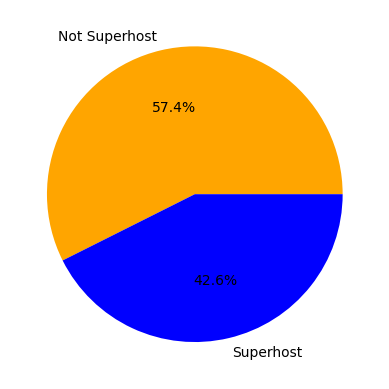

In [18]:
pie_superhost = plt.pie(vic_listings['host_is_superhost'].value_counts(), labels = ['Not Superhost', 'Superhost'], autopct = '%1.1f%%', colors = ['orange','blue'])
plt.show()

##### 42.6% of host are Superhost and remaning are not a Superhost.

In [21]:
plt.gcf().savefig(os.path.join(path, '04 Analysis', 'Visualizations', 'pie_chart_superhost.png'), dpi = 300, bbox_inches = 'tight')

### Top 10 properties types in Victoria

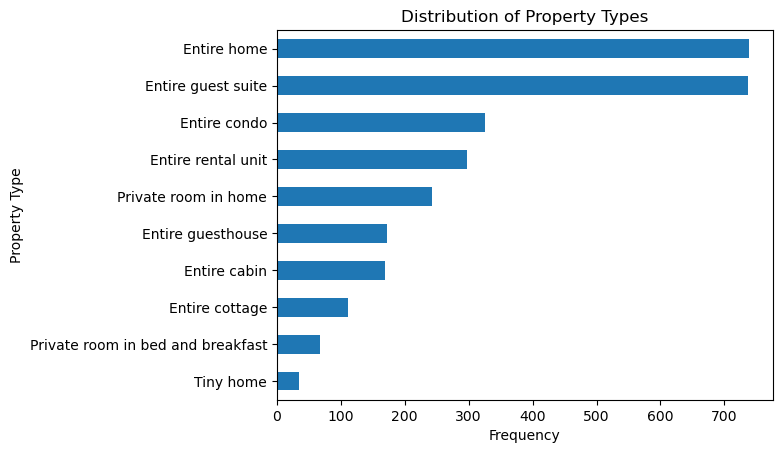

In [24]:
prop_freq = vic_listings['property_type'].value_counts().head(10).sort_values(ascending = True).plot.barh(xlabel = 'Frequency', ylabel = 'Property Type', title = 'Distribution of Property Types')
plt.show()

In [26]:
# Listings counts by property type
vic_listings['property_type'].value_counts().head(10)

property_type
Entire home                          739
Entire guest suite                   737
Entire condo                         325
Entire rental unit                   297
Private room in home                 243
Entire guesthouse                    173
Entire cabin                         169
Entire cottage                       112
Private room in bed and breakfast     68
Tiny home                             35
Name: count, dtype: int64

##### Highest listings are for Entire home. The listings for Entire home and Entire guest suite are almost similar.

In [29]:
# Saving figure
prop_freq.figure.savefig(os.path.join(path, '04 Analysis', 'Visualizations', 'property_frequency.png'))

### Top 10 property types by median Price

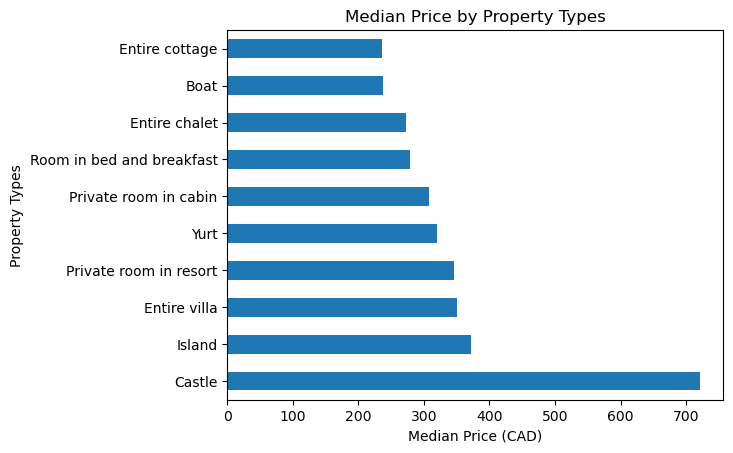

In [32]:
prop_price = vic_listings.groupby('property_type').agg({'price': 'median'}).sort_values(by = 'price', ascending = False).head(10).plot.barh(xlabel = 'Median Price (CAD)',
            ylabel = 'Property Types', title = 'Median Price by Property Types', legend = False)
plt.show()

##### Castle are the most expensive listing on Airbnb in Victoria.

In [35]:
# Saving figure
prop_price.figure.savefig(os.path.join(path, '04 Analysis', 'Visualizations', 'property_median_price.png'))

### Top 10 neigbhbourhoods by listings

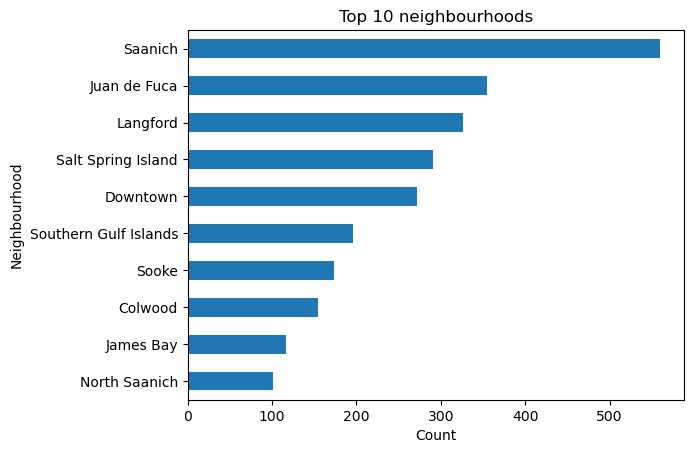

In [37]:
neigh_count = vic_listings['neighbourhood_cleansed'].value_counts(dropna = False).head(10).sort_values(ascending = True).plot.barh(
    title = 'Top 10 neighbourhoods', xlabel = 'Count', ylabel = 'Neighbourhood')
plt.show()

##### Saanich is the most popular neighbourhood by listing.

In [40]:
# Saving figure
neigh_count.figure.savefig(os.path.join(path, '04 Analysis', 'Visualizations', 'neighbourhood_count.png'))

### Top 10 priced neighbourhood (using median price)

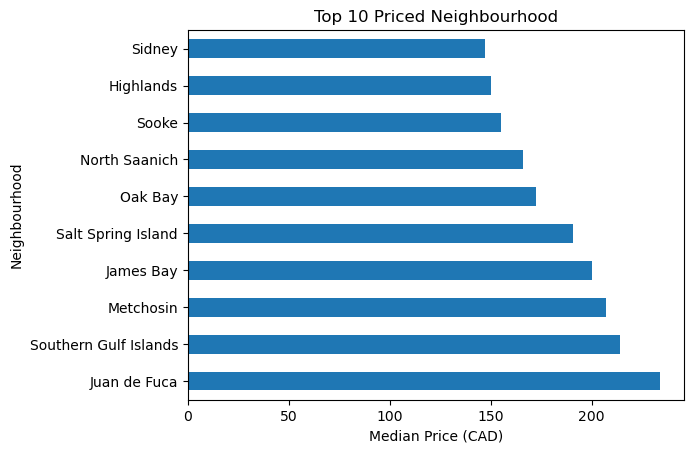

In [43]:
neigh_price = vic_listings.groupby('neighbourhood_cleansed').agg({'price': 'median'}).sort_values(by = 'price', ascending = False).head(10).plot.barh(
    xlabel = 'Median Price (CAD)', ylabel = 'Neighbourhood', title = 'Top 10 Priced Neighbourhood', legend = False)
plt.show()

##### Juan de Fuca is the most expensive neighbourhood.

In [46]:
# Saving figure
neigh_price.figure.savefig(os.path.join(path, '04 Analysis', 'Visualizations', 'neighbourhood_median_price.png'))

# 03 Exploring relationship between numerical variables

In [49]:
df1 = vic_listings[['price','accommodates', 'bathrooms', 'bedrooms', 'beds', 'minimum_nights','maximum_nights']]
df1.corr()

,price,accommodates,bathrooms,bedrooms,beds,minimum_nights,maximum_nights
price,1.000000,0.597392,0.580191,0.583198,0.572000,-0.115354,-0.000740
accommodates,0.597392,1.000000,0.688240,0.818351,0.843053,-0.043713,0.032738
bathrooms,0.580191,0.688240,1.000000,0.729857,0.618224,0.008677,-0.025534
bedrooms,0.583198,0.818351,0.729857,1.000000,0.745832,-0.009679,-0.025482
beds,0.572000,0.843053,0.618224,0.745832,1.000000,-0.059667,0.033818
minimum_nights,-0.115354,-0.043713,0.008677,-0.009679,-0.059667,1.000000,0.085743
maximum_nights,-0.000740,0.032738,-0.025534,-0.025482,0.033818,0.085743,1.000000


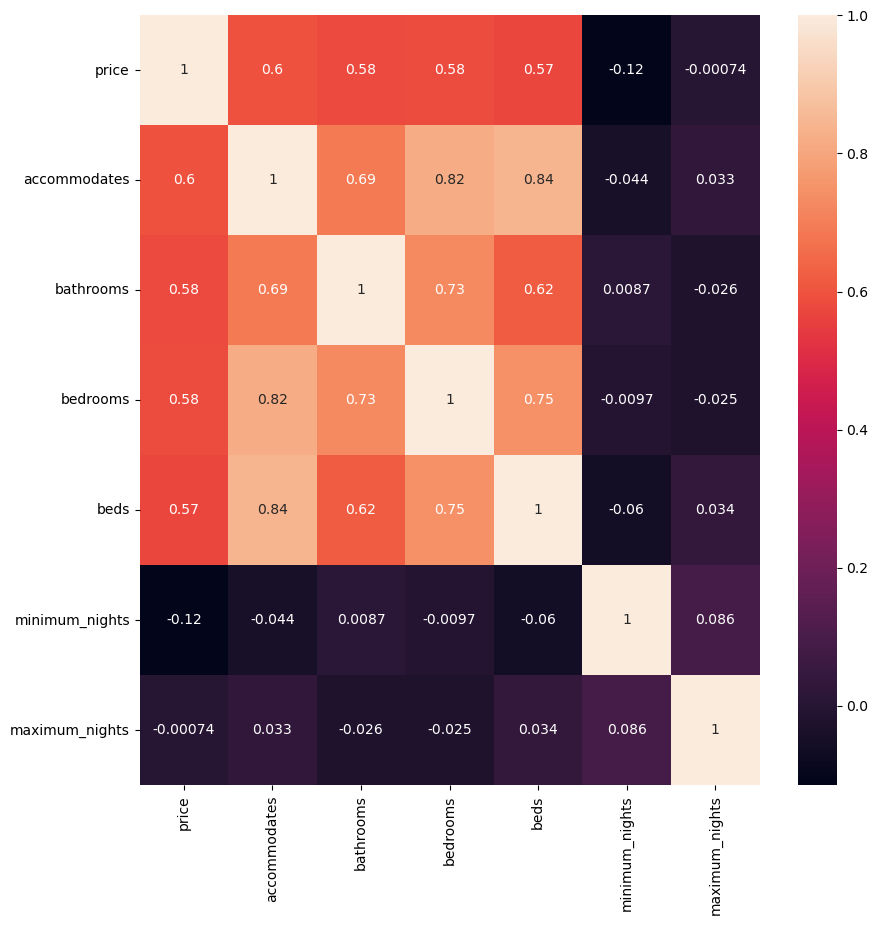

In [51]:
fig,ax = plt.subplots(figsize = (10,10))
corr_plot = sns.heatmap(df1.corr(), annot = True, ax = ax)
plt.show()

##### The price has a weak correlation with both minimum and maximum nights. However, it shows a stronger correlation with accommodates, bathrooms, bedrooms, and beds. Additionally, accommodates is highly correlated with both beds and bedrooms. Meanwhile, minimum and maximum nights exhibit a weak correlation with each other and with other variables.

In [54]:
df2 = vic_listings[['price', 'availability_30','availability_60', 'availability_90', 'availability_365', 'number_of_reviews', 'listings_count']]

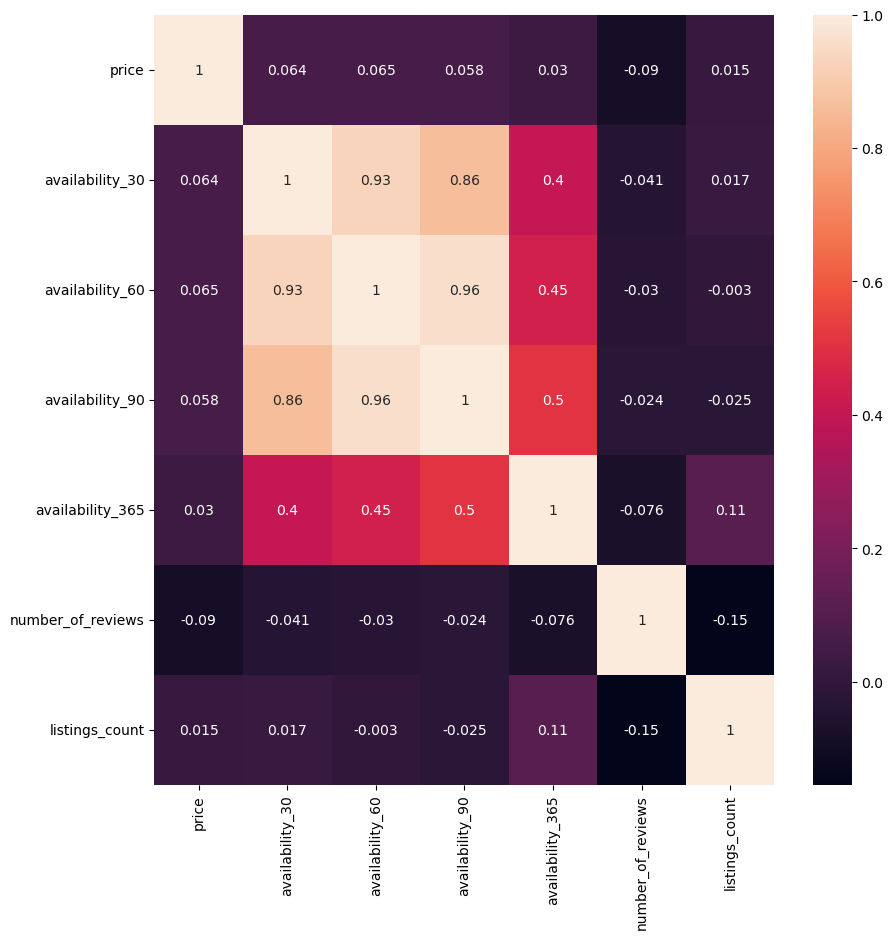

In [56]:
fig,ax = plt.subplots(figsize = (10,10))
corr_plot2 = sns.heatmap(df2.corr(), annot = True, ax = ax)
plt.show()

##### The price variable exhibits little to no correlation with other variables. Similarly, listings_count also demonstrates near-zero correlation with all other variables. However, availability_30, availability_60, and availability_90 show a strong correlation with one another. 

In [59]:
df3 = vic_listings[['price', 'review_scores_rating','review_scores_accuracy','review_scores_cleanliness', 'review_scores_checkin',
                    'review_scores_communication','review_scores_location','review_scores_value','reviews_per_month','host_acceptance_rate']]

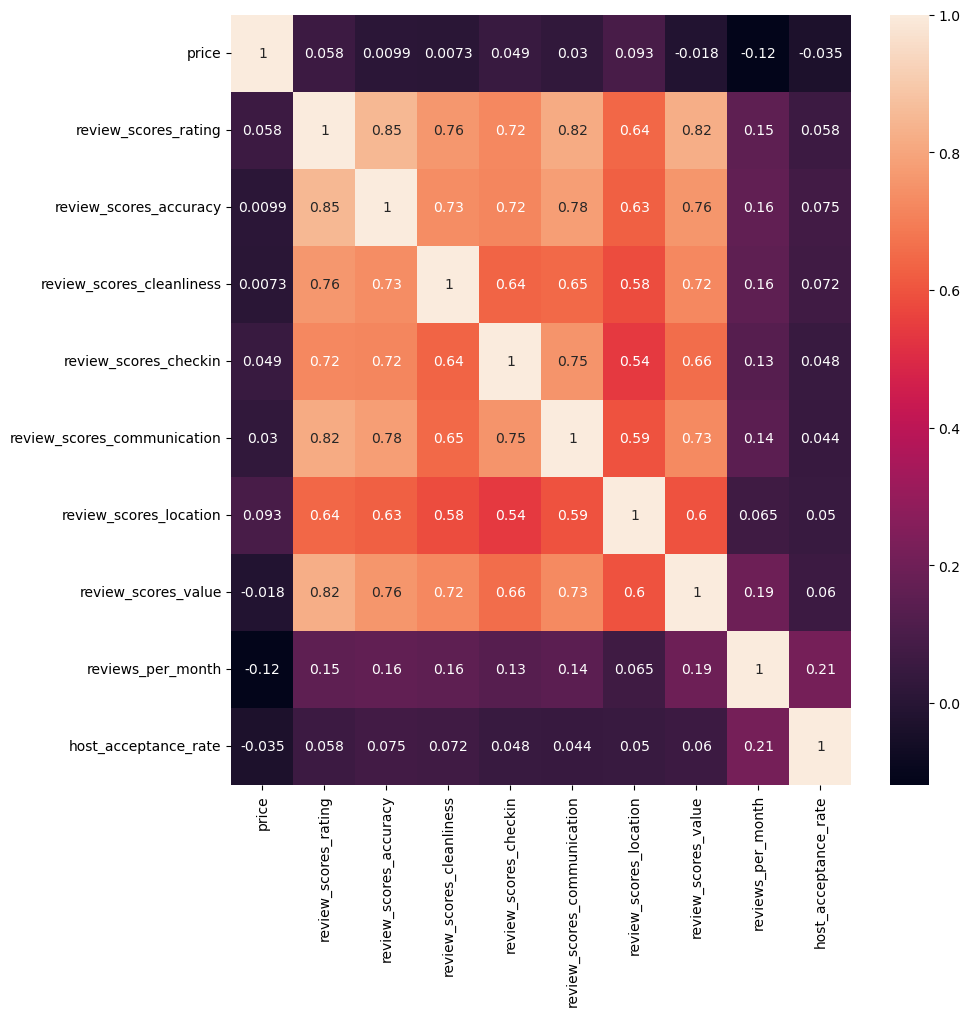

In [61]:
fig,ax = plt.subplots(figsize = (10,10))
corr_plot3 = sns.heatmap(df3.corr(), annot = True, ax = ax)
plt.show()

##### The price and host_acceptance_rate has little to no correlation with each other and other variables. The review_scores_rating has moderate to strong linear correlation to other review variables except for reviews_per_month.

# 04 Scatter plot of the variables with strong correlation

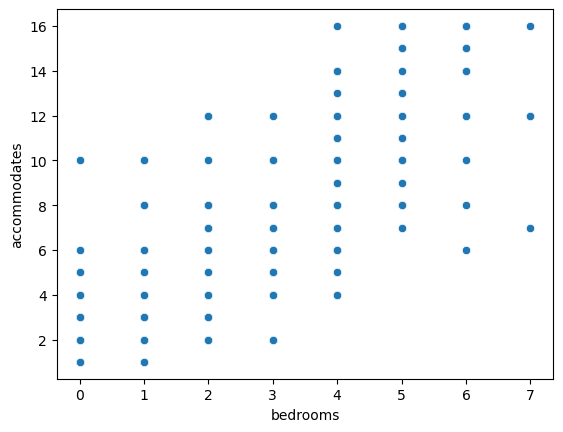

In [65]:
# Accomodates and bedrooms plot
sns.scatterplot(x = vic_listings['bedrooms'], y = vic_listings['accommodates'])
plt.show()

##### There is an upward trend in the plot, indicating that as the number of bedrooms increases, the capacity to accommodate more people also rises.

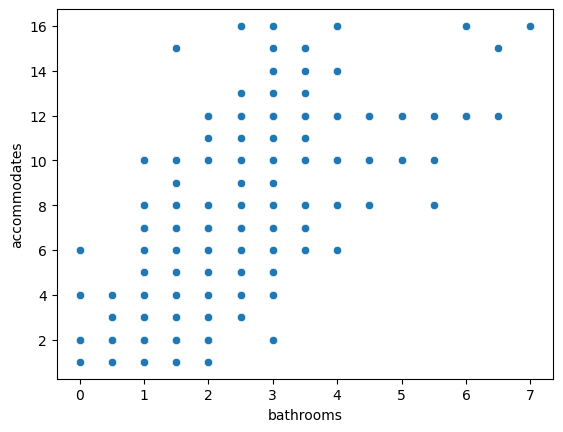

In [68]:
# Accomodates and bathrooms plot
sns.scatterplot(x = vic_listings['bathrooms'], y = vic_listings['accommodates'])
plt.show()

##### There is an upward trend in the plot, indicating that as the number of bathrooms increases, the capacity to accommodate more people also rises.

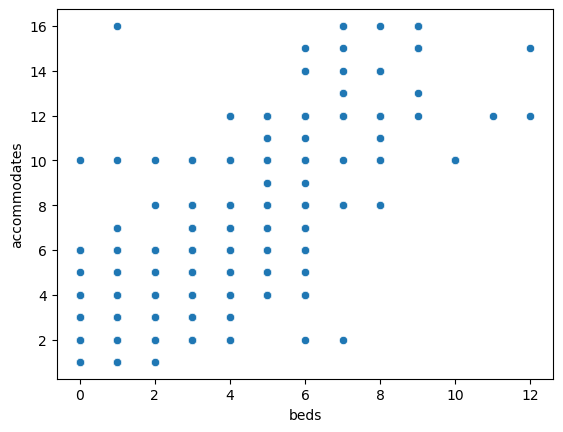

In [71]:
# Accommodates and beds plot
sns.scatterplot(x = vic_listings['beds'], y = vic_listings['accommodates'])
plt.show()

##### There is an upward trend in the plot, indicating that as the number of beds increases, the capacity to accommodate more people also rises.

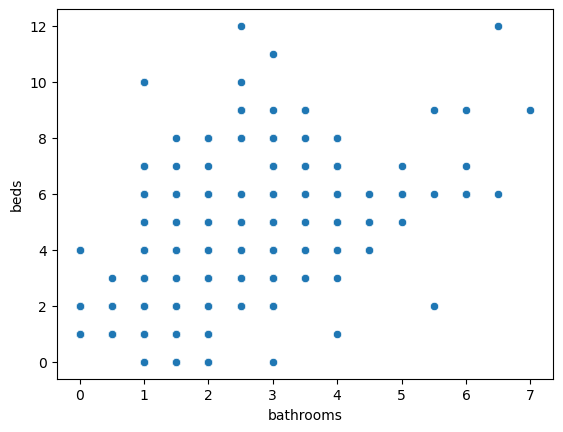

In [74]:
# Beds and bathrooms plot
sns.scatterplot(x = vic_listings['bathrooms'], y = vic_listings['beds'])
plt.show()

##### There is an upward trend in the plot, indicating that as the number of bathrooms increases, the number of beds also increases.

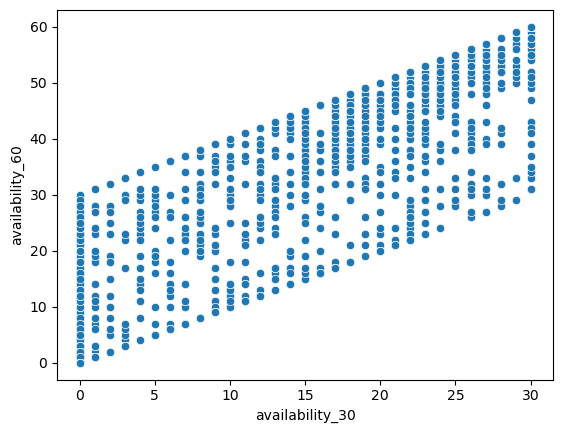

In [77]:
# Availability_30 and availability_60 plot
sns.scatterplot(x = vic_listings['availability_30'], y = vic_listings['availability_60'])
plt.show()

##### There is a clear linear trend in the plot. If a listing is available more frequently in the next 30 days, it is also more likely to be available in the next 60 days.

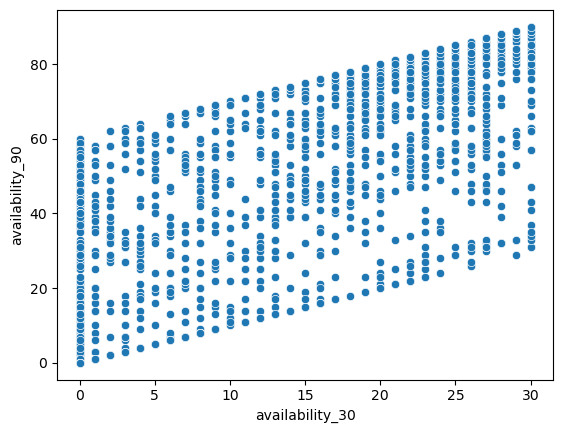

In [80]:
# Availability_30 and availability_90 plot
sns.scatterplot(x = vic_listings['availability_30'], y = vic_listings['availability_90'])
plt.show()

##### A similar linear trend is observed with availability_30 and availability_90, though the correlation is slightly weaker.

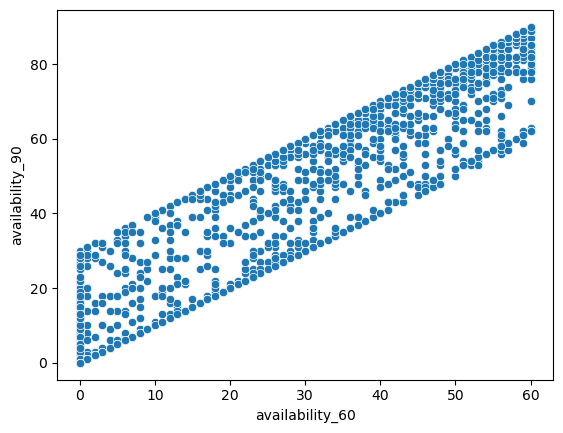

In [83]:
# Availability_90 and availability_60 plot
sns.scatterplot(x = vic_listings['availability_60'], y = vic_listings['availability_90'])
plt.show()

##### There is a strong correlation between availability_60 and availability_90. Listings that are frequently available in the next 60 days are also likely to be available in the next 90 days.

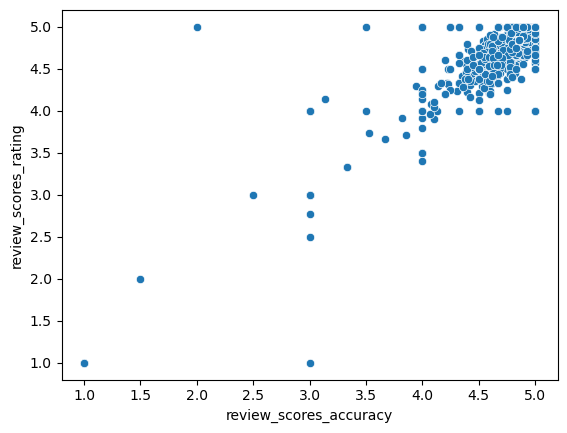

In [86]:
# Review_scores_rating and review_scores_accuracy
sns.scatterplot(x = vic_listings['review_scores_accuracy'], y = vic_listings['review_scores_rating'])
plt.show()

##### Maximum scores are concentrated at the higher end, with only a few scattered reviews.

# 05 Pair Plot of the dataset

In [90]:
# Check shape
vic_listings.shape

(3298, 44)

##### Since there are 44 variables, we will select only the numerical and key features for the pair plot to ensure readability.

In [93]:
# Columns in dataset
vic_listings.columns

Index(['id', 'scrape_id', 'host_id', 'host_since', 'host_response_rate',
       'host_acceptance_rate', 'host_is_superhost', 'host_identity_verified',
       'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'latitude',
       'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms',
       'bedrooms', 'beds', 'amenities', 'price', 'minimum_nights',
       'maximum_nights', 'has_availability', 'availability_30',
       'availability_60', 'availability_90', 'availability_365',
       'calendar_last_scraped', 'number_of_reviews', 'number_of_reviews_ltm',
       'number_of_reviews_l30d', 'review_scores_rating',
       'review_scores_accuracy', 'review_scores_cleanliness',
       'review_scores_checkin', 'review_scores_communication',
       'review_scores_location', 'review_scores_value', 'instant_bookable',
       'listings_count', 'listings_count_home', 'listings_count_p_rooms',
       'listings_count_s_rooms', 'reviews_per_month'],
      dtype='object')

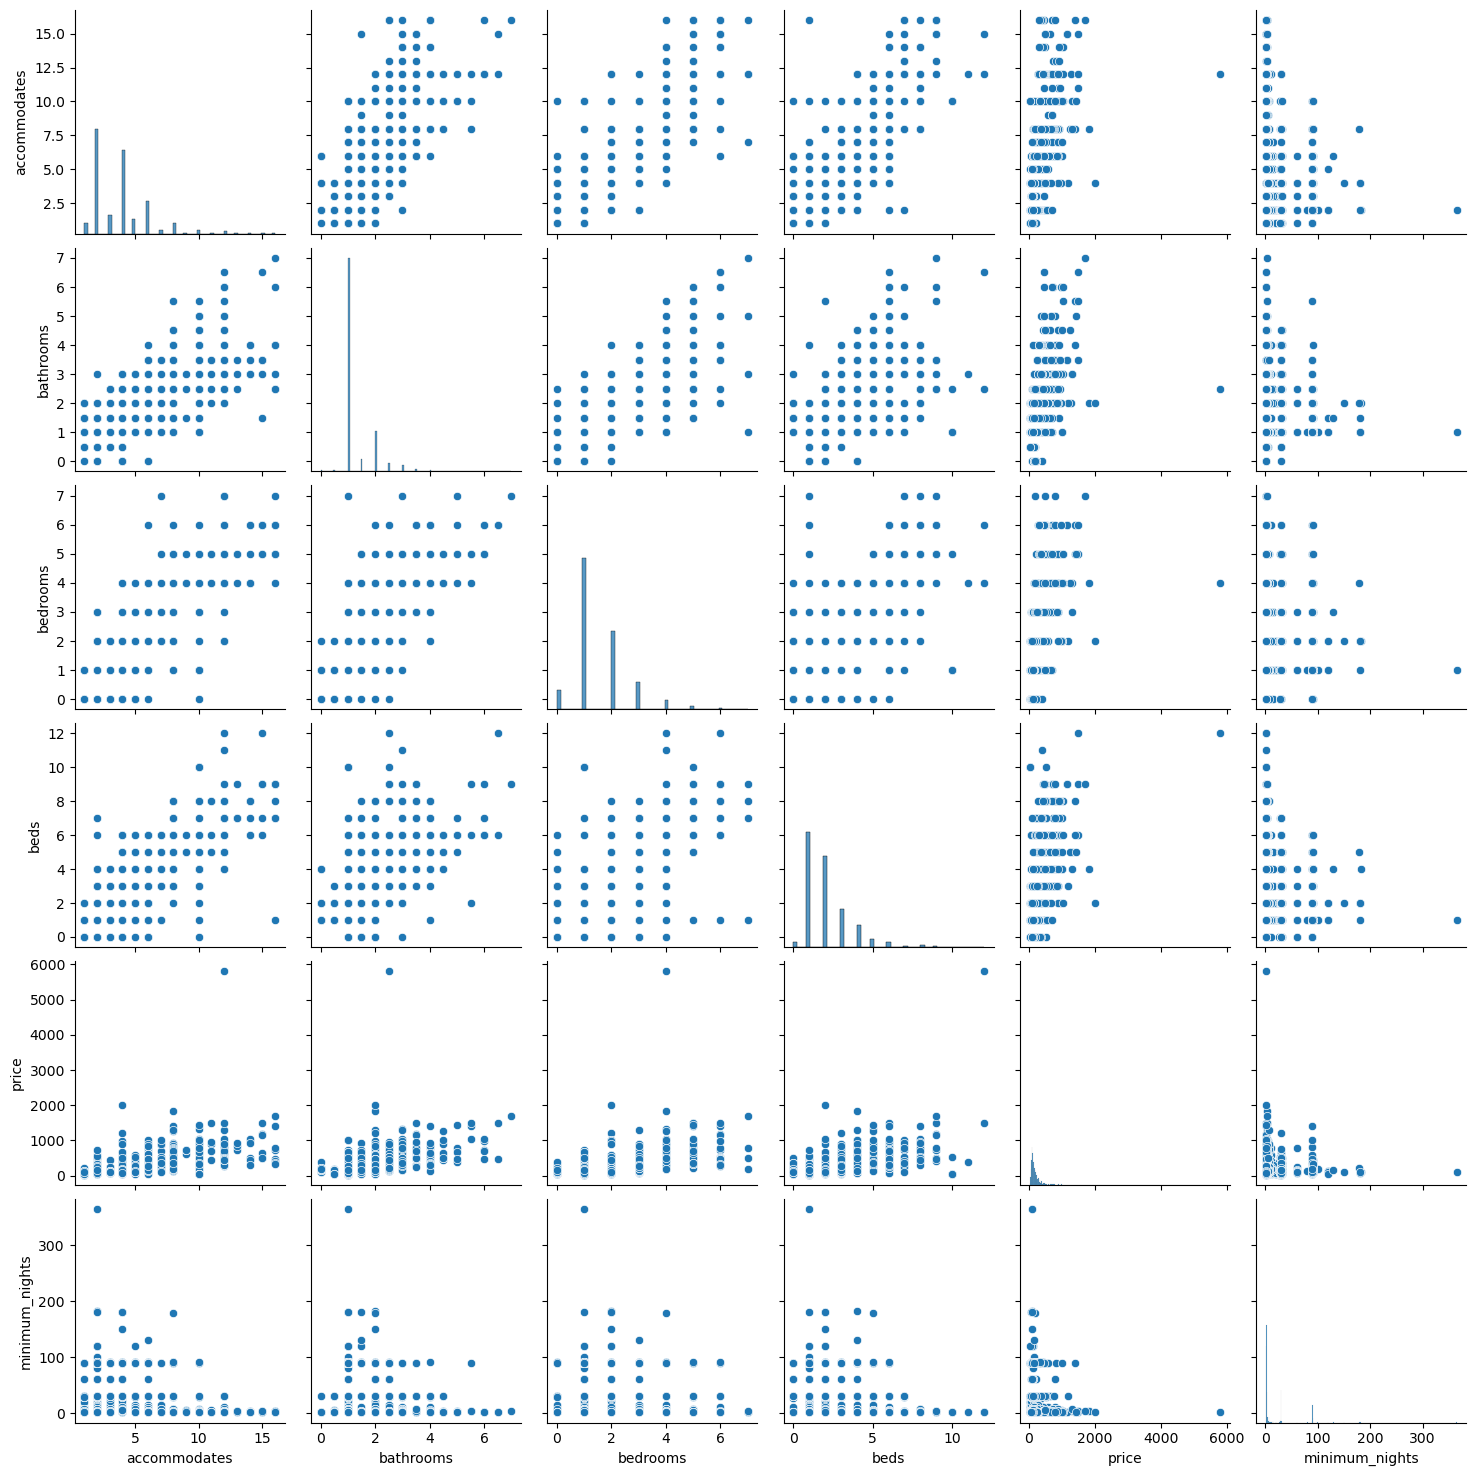

In [95]:
pair_plot = sns.pairplot(vic_listings[['accommodates','bathrooms', 'bedrooms', 'beds','price', 'minimum_nights']])
plt.show()

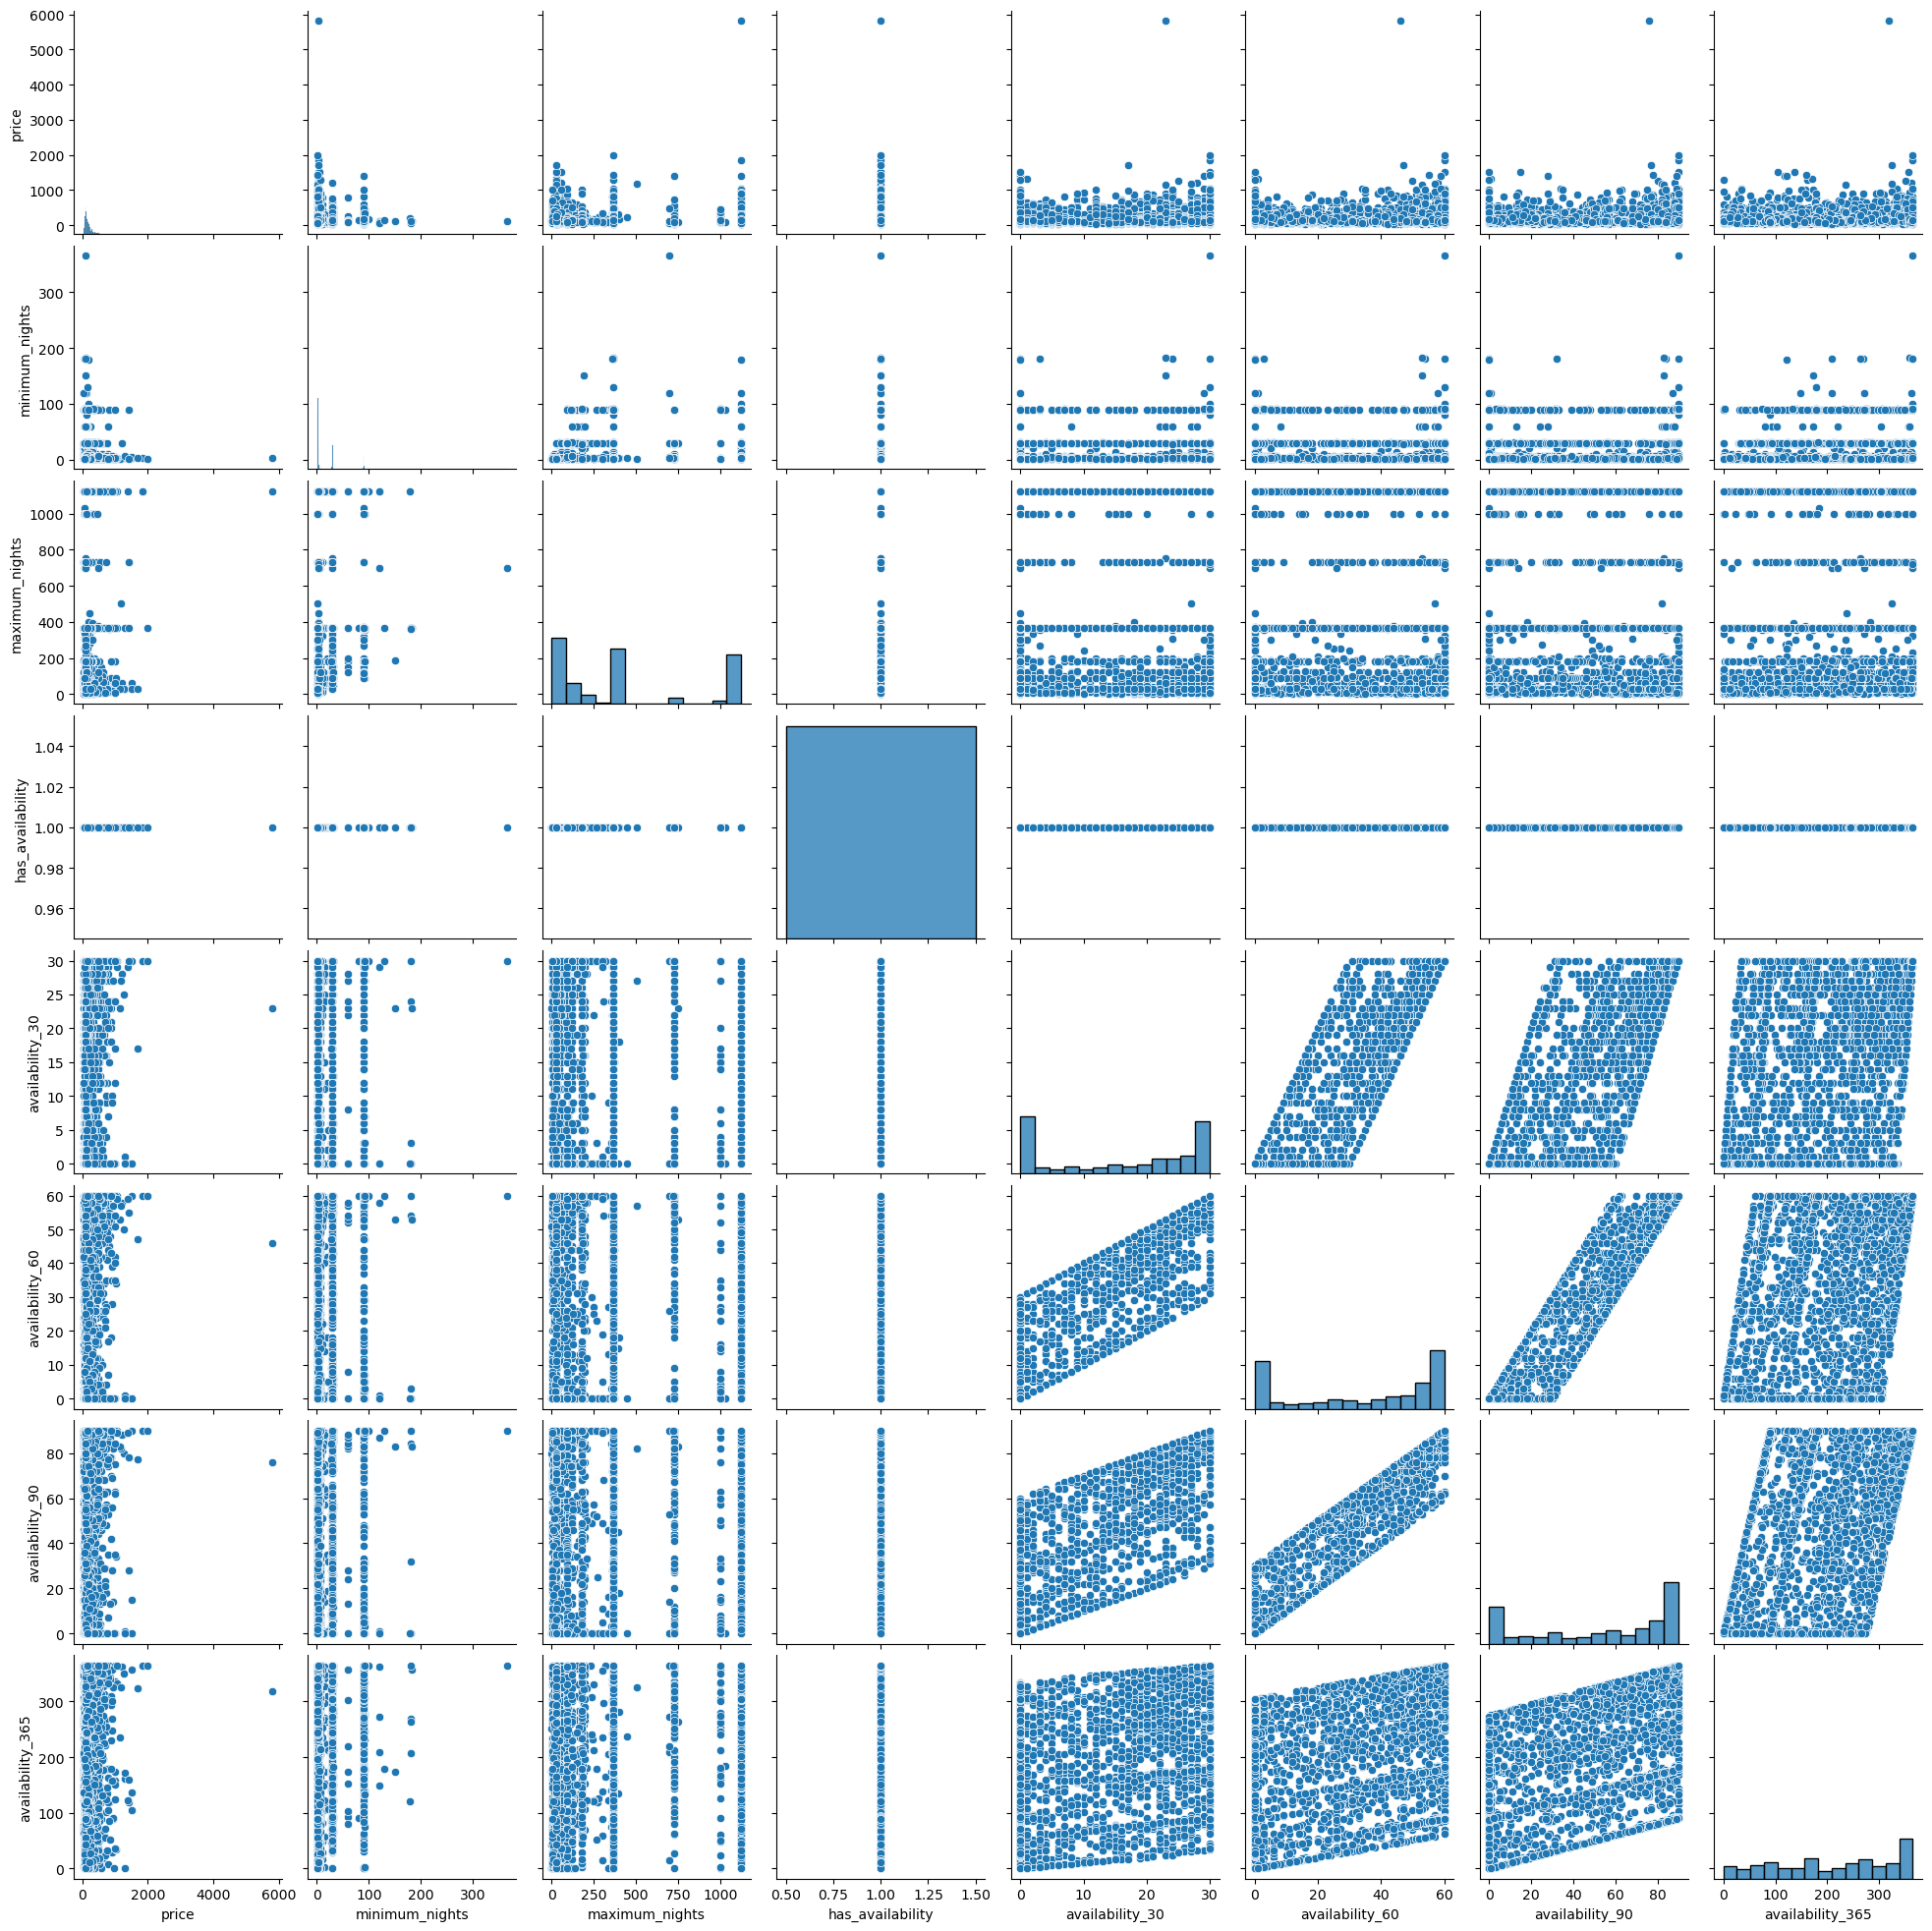

In [96]:
pair_plot2 = sns.pairplot(vic_listings[['price', 'minimum_nights','maximum_nights', 'has_availability', 'availability_30','availability_60',
                                        'availability_90', 'availability_365']])
plt.show()

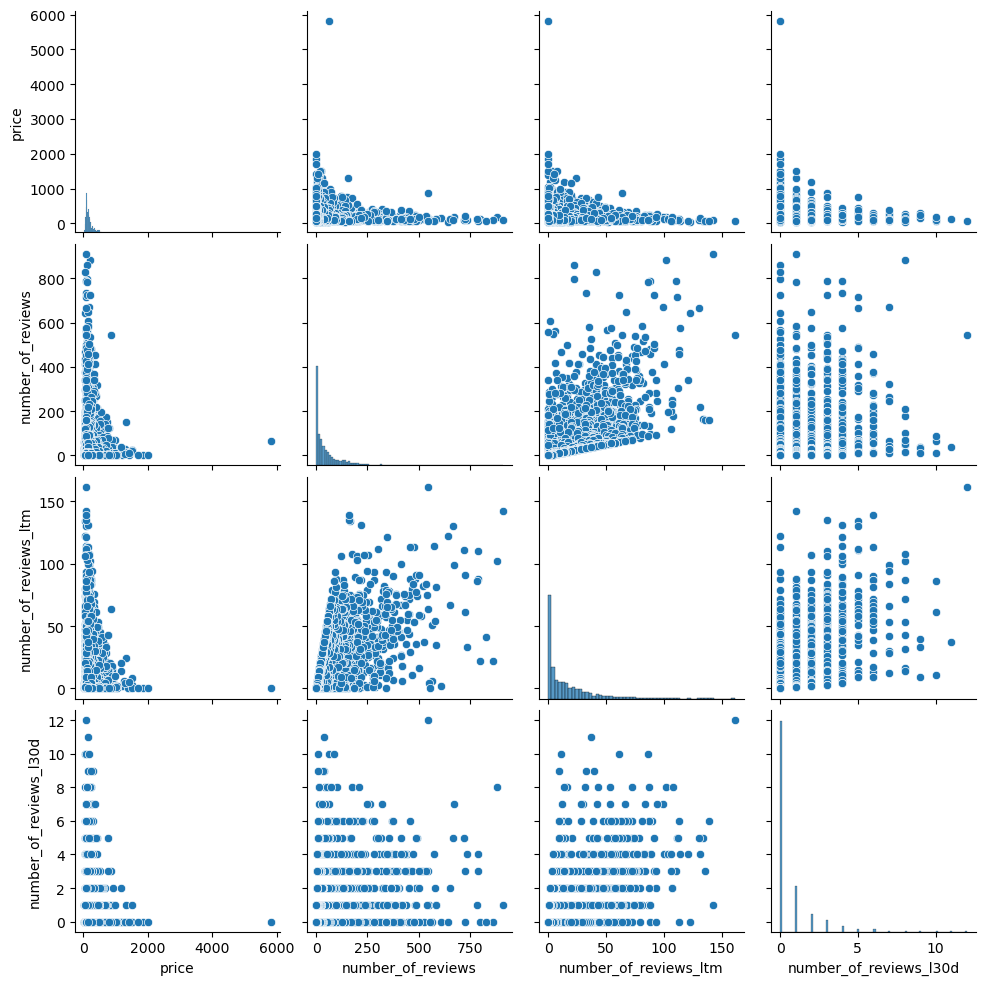

In [97]:
pair_plot3 = sns.pairplot(vic_listings[['price', 'number_of_reviews', 'number_of_reviews_ltm','number_of_reviews_l30d']])
plt.show()

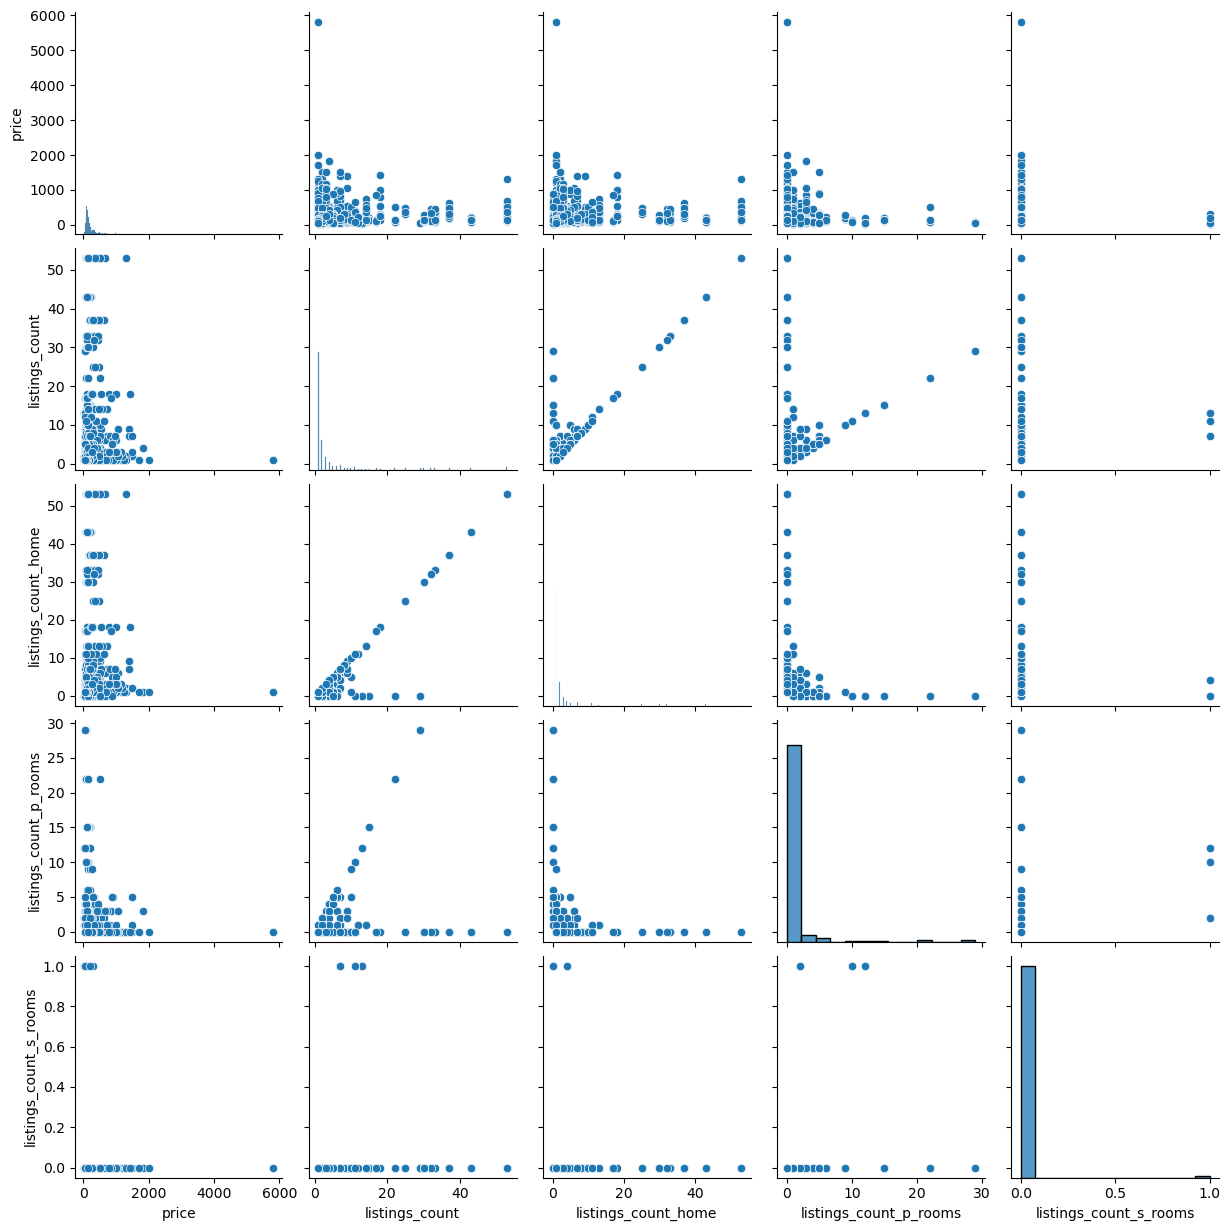

In [98]:
pair_plot4 = sns.pairplot(vic_listings[['price','listings_count', 'listings_count_home', 'listings_count_p_rooms', 'listings_count_s_rooms']])
plt.show()

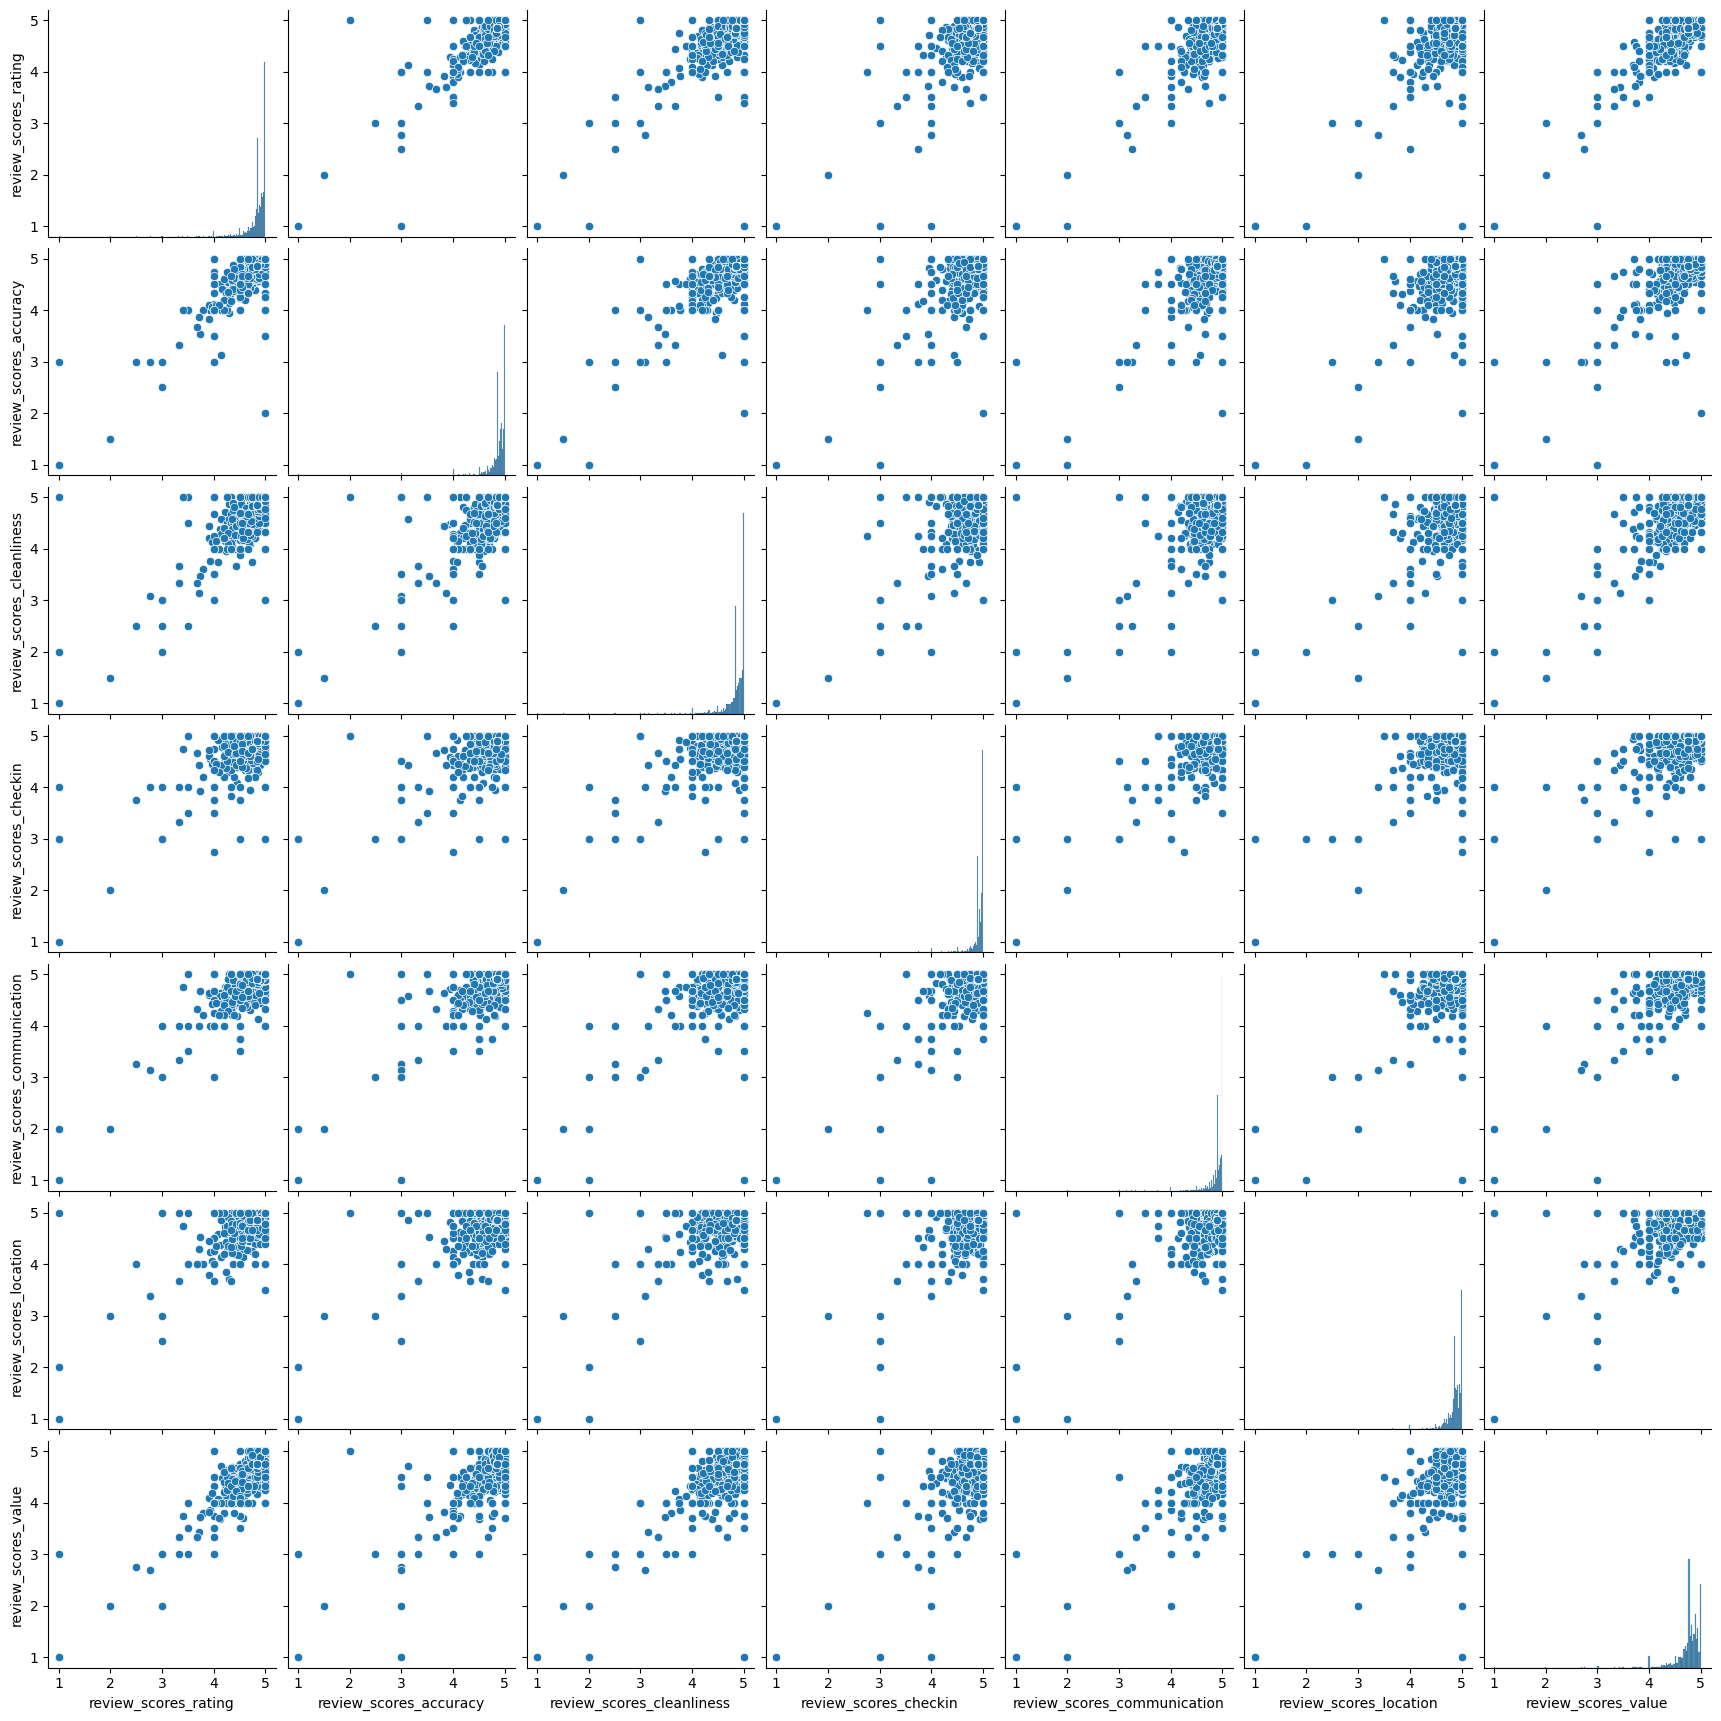

In [99]:
pair_plot5 = sns.pairplot(vic_listings[['review_scores_rating', 'review_scores_accuracy', 'review_scores_cleanliness', 'review_scores_checkin',
       'review_scores_communication', 'review_scores_location', 'review_scores_value']])
plt.show()

##### I want to analyze the distribution of prices, as the data appears widely spread due to outliers. Examining the characteristics of these outliers could provide valuable insights. Additionally, I plan to explore the distribution of availability over 30, 60, and 90 days, all of which exhibit a bi-modal pattern. Understanding the reasons behind this bi-modality could offer further clarity on the data trends.

# 06 Creating categorical plots

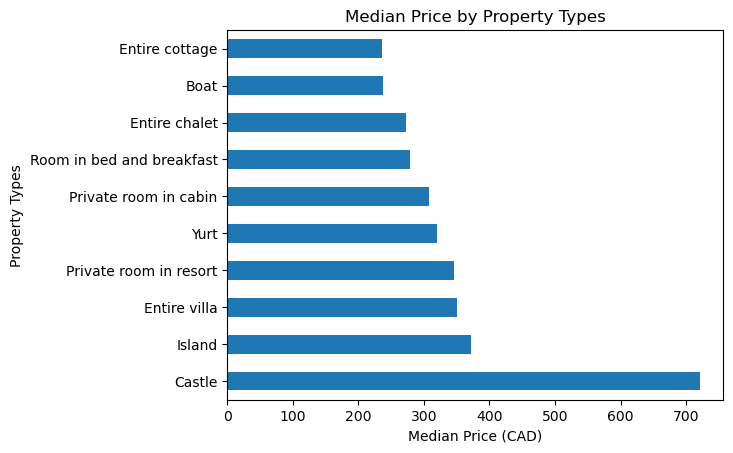

In [102]:
# Top 10 property types by median Price
prop_price = vic_listings.groupby('property_type').agg({'price': 'median'}).sort_values(by = 'price', ascending = False).head(10).plot.barh(xlabel = 'Median Price (CAD)',
            ylabel = 'Property Types', title = 'Median Price by Property Types', legend = False)
plt.show()

##### The Castle, Island, Entire Villa, Private Room in Resort, and Yurt are the highest-priced listings. The cost of the Castle is nearly double that of the second most expensive listing, the Island.

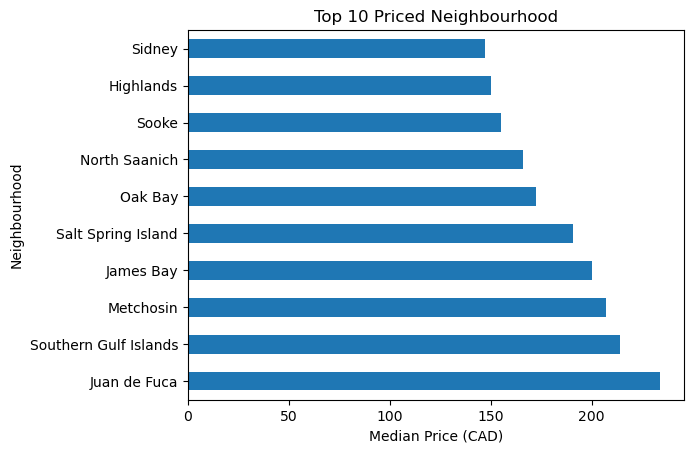

In [104]:
# Top 10 priced neighbourhood (using median price)
neigh_price = vic_listings.groupby('neighbourhood_cleansed').agg({'price': 'median'}).sort_values(by = 'price', ascending = False).head(10).plot.barh(
    xlabel = 'Median Price (CAD)', ylabel = 'Neighbourhood', title = 'Top 10 Priced Neighbourhood', legend = False)
plt.show()

##### The top five expensive neighbourhoods are Juan de Fuca, Southern Gulf Islands, Metchosin, James Bay and Salt Spring Island.